In [1]:
# Lecture 6
# import packages
from scipy.stats import logistic
from scipy.stats import norm
from scipy.stats import chi2
from scipy.optimize import root_scalar
from scipy.special import logit, expit

from statsmodels.formula.api import glm
from statsmodels.genmod.families import Binomial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
# os.chdir(r'C:\Users\Linda\Desktop\ST5213py')
pd.set_option("display.width", 2000)

# import custom functions
from ST5213_helpers import *

# fig_save_dir = r'C:/Users/Linda/OneDrive - National University of Singapore/ST5213 2627/Lectures/Lecture_6/figure'

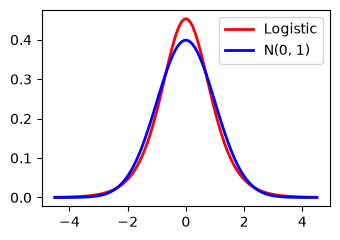

In [2]:
x = np.linspace(-4.5, 4.5, 100)
plt.figure(figsize=(3.5, 2.5))
plt.plot(x, logistic.pdf(x, loc=0, scale=np.sqrt(3)/np.pi), 'r-', lw=2, label=f'Logistic')
plt.plot(x, norm.pdf(x, loc=0, scale=1), 'b-', lw=2, label=f'N(0, 1)')
plt.tight_layout() 
plt.legend()

# fig_path = os.path.join(fig_save_dir, 'logistic.pdf')
# plt.savefig(fig_path, bbox_inches='tight')  

plt.show()

In [3]:
# Read beetles dataset
df = pd.read_csv('dataset/beetles.txt', sep=' ')
print(df,'\n')
print(df.info())

# Compute observed proportions
df['prop'] = df['Mortality'] / df['Exposed'] 

# Create a variable to represent failures
df['fail'] = df['Exposed'] - df['Mortality']

     Dose  Exposed  Mortality
0  1.6907       59          6
1  1.7242       60         13
2  1.7552       62         18
3  1.7842       56         28
4  1.8113       63         52
5  1.8369       59         53
6  1.8610       62         61
7  1.8839       60         60 

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Dose       8 non-null      float64
 1   Exposed    8 non-null      int64  
 2   Mortality  8 non-null      int64  
dtypes: float64(1), int64(2)
memory usage: 324.0 bytes
None


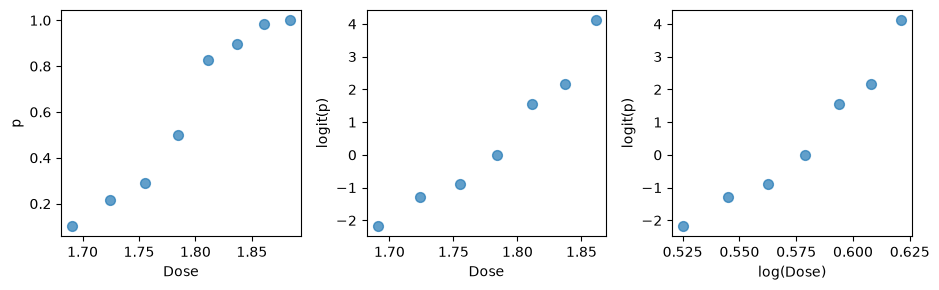

In [4]:
# Visualize data 
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(9.5, 3))

axes[0].scatter(df['Dose'], df['prop'], s=50, alpha=0.7)
axes[0].set_xlabel('Dose')
axes[0].set_ylabel('p')

axes[1].scatter(df['Dose'], logit(df['prop']), s=50, alpha=0.7)
axes[1].set_xlabel('Dose')
axes[1].set_ylabel('logit(p)')

axes[2].scatter(np.log(df['Dose']), logit(df['prop']), s=50, alpha=0.7)
axes[2].set_xlabel('log(Dose)')
axes[2].set_ylabel('logit(p)')

plt.tight_layout()

# fig_path = os.path.join(fig_save_dir, 'propvsdose.pdf')
# fig.savefig(fig_path, bbox_inches='tight')  

plt.show()

In [5]:
# Fit logistic regresion model in Dose
# Create a variable to represent failures
df['fail'] = df['Exposed'] - df['Mortality']

fm1 = glm('Mortality + fail ~ Dose', df, family=Binomial()).fit()
print(fm1.summary2(),'\n')

# Goodness of fit test
print(chi2.sf(fm1.deviance, fm1.df_resid))

                Results: Generalized linear model
Model:              GLM                   Method:         IRLS   
Model Family:       Binomial              AIC:            41.4303
Link Function:      Logit                 BIC:            41.5892
Dependent Variable: ['Mortality', 'fail'] Log-Likelihood: -18.715
Date:               2026-09-14 09:44      LL-Null:        -155.20
No. Observations:   8                     Deviance:       11.232 
Df Model:           1                     Pearson chi2:   10.0   
Df Residuals:       6                     Scale:          1.0000 
-----------------------------------------------------------------
               Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
-----------------------------------------------------------------
Intercept     -60.7175   5.1807 -11.7199 0.0000 -70.8715 -50.5634
Dose           34.2703   2.9121  11.7681 0.0000  28.5626  39.9780
 

0.08145880992733505


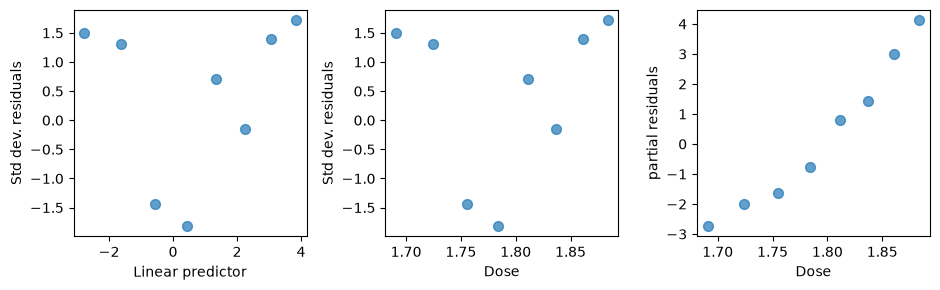

In [6]:
# Residual plots
res_deviance_std = fm1.resid_deviance / np.sqrt(1-hat_diag(fm1))
res_working = fm1.resid_working / (df['Exposed'] ** 2) 
res_partial = res_working + (df['Dose'] - np.mean(df['Dose'])) * fm1.params['Dose']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(9.5, 3))

axes[0].scatter(fm1.predict(df, which='linear'), res_deviance_std, s=50, alpha=0.7)
axes[0].set_xlabel('Linear predictor')
axes[0].set_ylabel('Std dev. residuals')

axes[1].scatter(df['Dose'], res_deviance_std, s=50, alpha=0.7)
axes[1].set_xlabel('Dose')
axes[1].set_ylabel('Std dev. residuals')

axes[2].scatter(df['Dose'], res_partial, s=50, alpha=0.7)
axes[2].set_xlabel('Dose')
axes[2].set_ylabel('partial residuals')

plt.tight_layout()

# fig_path = os.path.join(fig_save_dir, 'residuals_fm1.pdf')
# fig.savefig(fig_path, bbox_inches='tight')  

plt.show()

In [7]:
# Quadratic model in Dose
fm2 = update_glm(fm1, add='I(Dose**2)')
print(fm2.summary2())
print(chi2.sf(fm2.deviance, fm2.df_resid),'\n')

                Results: Generalized linear model
Model:               GLM                   Method:         IRLS   
Model Family:        Binomial              AIC:            35.3929
Link Function:       Logit                 BIC:            35.6313
Dependent Variable:  ['Mortality', 'fail'] Log-Likelihood: -14.696
Date:                2026-09-14 09:44      LL-Null:        -155.20
No. Observations:    8                     Deviance:       3.1949 
Df Model:            2                     Pearson chi2:   3.00   
Df Residuals:        5                     Scale:          1.0000 
------------------------------------------------------------------
               Coef.   Std.Err.    z    P>|z|    [0.025    0.975] 
------------------------------------------------------------------
Intercept     431.1058 180.6536  2.3864 0.0170   77.0312  785.1804
Dose         -520.6153 204.5226 -2.5455 0.0109 -921.4721 -119.7584
I(Dose ** 2)  156.4116  57.8630  2.7031 0.0069   43.0021  269.8210

0.669965965

In [8]:
# Cubic model in Dose
fm3 = update_glm(fm2, add='I(Dose**3)')
print(fm3.summary2())
print(chi2.sf(fm3.deviance, fm3.df_resid))

                   Results: Generalized linear model
Model:                 GLM                     Method:           IRLS   
Model Family:          Binomial                AIC:              37.1194
Link Function:         Logit                   BIC:              37.4372
Dependent Variable:    ['Mortality', 'fail']   Log-Likelihood:   -14.560
Date:                  2026-09-14 09:44        LL-Null:          -155.20
No. Observations:      8                       Deviance:         2.9214 
Df Model:              3                       Pearson chi2:     2.79   
Df Residuals:          4                       Scale:            1.0000 
------------------------------------------------------------------------
               Coef.     Std.Err.     z    P>|z|     [0.025     0.975]  
------------------------------------------------------------------------
Intercept    -2898.9230  6518.3566 -0.4447 0.6565 -15674.6671  9876.8212
Dose          5124.6079 11052.5723  0.4637 0.6429 -16538.0357 26787.251

In [9]:
print(anova_nested(fm1, fm2, fm3))

         Resid. Df  Resid. Dev   Df  Deviance  Pr(>Chi)
Model 1        6.0   11.232231  NaN       NaN       NaN
Model 2        5.0    3.194905  1.0  8.037326  0.004582
Model 3        4.0    2.921361  1.0  0.273544  0.600964


In [10]:
print(drop1_glm(fm2))

             Df   Deviance        AIC       LRT  Pr(>Chi)
<none>            3.194905  35.392944                    
Dose          1  10.236983  40.435021  7.042077  0.007962
I(Dose ** 2)  1  11.232231  41.430269  8.037326  0.004582


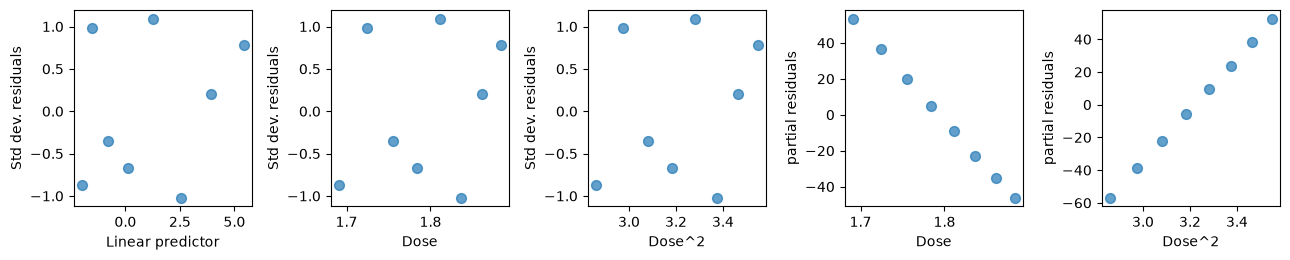

In [11]:
# Residual plots for fm2
res_deviance_std = fm2.resid_deviance / np.sqrt(1-hat_diag(fm2))
res_working = fm2.resid_working / (df['Exposed'] ** 2) 
res_partial1 = res_working + (df['Dose'] - np.mean(df['Dose'])) * fm2.params['Dose']
res_partial2 = res_working + (df['Dose']**2 - np.mean(df['Dose']**2)) * fm2.params['I(Dose ** 2)']

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(13, 2.7))

axes[0].scatter(fm2.predict(df, which='linear'), res_deviance_std, s=50, alpha=0.7)
axes[0].set_xlabel('Linear predictor')
axes[0].set_ylabel('Std dev. residuals')

axes[1].scatter(df['Dose'], res_deviance_std, s=50, alpha=0.7)
axes[1].set_xlabel('Dose')
axes[1].set_ylabel('Std dev. residuals')

axes[2].scatter(df['Dose']**2, res_deviance_std, s=50, alpha=0.7)
axes[2].set_xlabel('Dose^2')
axes[2].set_ylabel('Std dev. residuals')

axes[3].scatter(df['Dose'], res_partial1, s=50, alpha=0.7)
axes[3].set_xlabel('Dose')
axes[3].set_ylabel('partial residuals')

axes[4].scatter(df['Dose']**2, res_partial2, s=50, alpha=0.7)
axes[4].set_xlabel('Dose^2')
axes[4].set_ylabel('partial residuals')

plt.tight_layout()

# fig_path = os.path.join(fig_save_dir, 'residuals_fm2.pdf')
# fig.savefig(fig_path, bbox_inches='tight')  

plt.show()

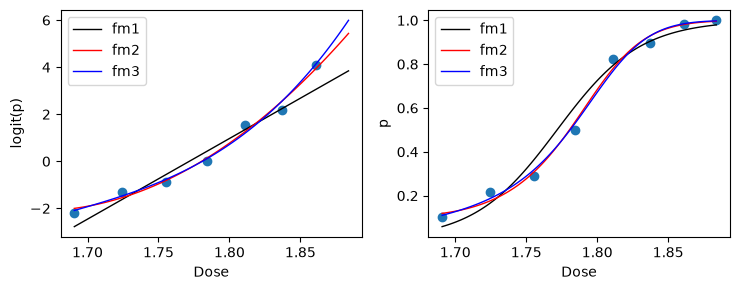

In [12]:
# predictions from fm2 
doses = np.linspace(min(df['Dose']), max(df['Dose']), 100)
pred_df = pd.DataFrame({'Dose': doses}) 

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7.5, 3))

axes[0].scatter(df['Dose'], logit(df['prop']))
axes[0].plot(doses, fm1.predict(pred_df, which='linear'), color='black', lw=1, label=f'fm1')
axes[0].plot(doses, fm2.predict(pred_df, which='linear'), 'r-', lw=1, label=f'fm2')
axes[0].plot(doses, fm3.predict(pred_df, which='linear'), 'b-', lw=1, label=f'fm3')
axes[0].legend()
axes[0].set_xlabel('Dose')
axes[0].set_ylabel('logit(p)')

axes[1].scatter(df['Dose'], df['prop'])
axes[1].plot(doses, fm1.predict(pred_df), color='black', lw=1, label=f'fm1')
axes[1].plot(doses, fm2.predict(pred_df), 'r-', lw=1, label=f'fm2')
axes[1].plot(doses, fm3.predict(pred_df), 'b-', lw=1, label=f'fm3')
axes[1].legend()
axes[1].set_xlabel('Dose')
axes[1].set_ylabel('p')

plt.tight_layout() 

# fig_path = os.path.join(fig_save_dir, 'predict_fm2.pdf')
# fig.savefig(fig_path, bbox_inches='tight')  

plt.show()


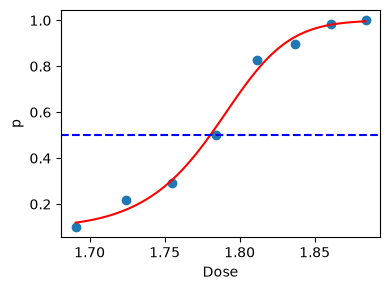

In [13]:
# LD50 plot
plt.figure(figsize=(4, 3))
plt.scatter(df['Dose'], df['prop'])
plt.plot(doses, fm2.predict(pred_df), 'r-')
plt.axhline(0.5, color='blue', linestyle='--')
plt.xlabel('Dose')
plt.ylabel('p')
plt.tight_layout() 

# fig_path = os.path.join(fig_save_dir, 'LD50.pdf')
# plt.savefig(fig_path, bbox_inches='tight')  

plt.show()

In [14]:
# Solving for LD using formula
beta = np.array(fm2.params)

def LD(p):
    zeta = logit(p)
    return (-beta[1] + np.array([-1,1])*np.sqrt(beta[1]**2 - 4*beta[2]*(beta[0]-zeta)))/(2*beta[2])

print('LD50:', LD(0.5))  
print('LD90:', LD(0.9))  
print('min Dose:', min(df['Dose']), ', max Dose:', max(df['Dose']))

LD50: [1.54808381 1.78041209]
LD90: [1.49829067 1.83020523]
min Dose: 1.6907 , max Dose: 1.8839


In [15]:
# Solving for LD numerically 

def f(x):
    pred_df = pd.DataFrame({'Dose': [x]}) 
    pred_value = fm2.predict(pred_df, which='linear')[0]
    return pred_value - logit(p)

p = 0.5
LD50 = root_scalar(f, bracket=[min(df['Dose']), max(df['Dose'])], method='brentq')
print(LD50.root)

p = 0.9
LD90 = root_scalar(f, bracket=[min(df['Dose']), max(df['Dose'])], method='brentq')
print(LD90.root)

1.7804120895269746
1.8302052307217378


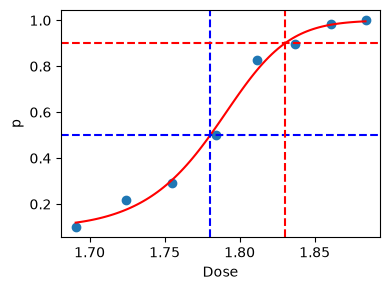

In [16]:
# Visualiuze LD50 and LD 90
plt.figure(figsize=(4, 3))
plt.scatter(df['Dose'], df['prop'])
plt.plot(doses, fm2.predict(pred_df), 'r-')

plt.axhline(0.5, color='blue', linestyle='--')
plt.axvline(LD50.root, color='blue', linestyle='--')

plt.axhline(0.9, color='red', linestyle='--')
plt.axvline(LD90.root, color='red', linestyle='--')

plt.xlabel('Dose')
plt.ylabel('p')
plt.tight_layout() 

# fig_path = os.path.join(fig_save_dir, 'fittedLD.pdf')
# plt.savefig(fig_path, bbox_inches='tight')  

plt.show()

In [17]:
# CI for LD50 and LD90
def compute_LD_CI(x, beta):
    dm = beta[1] + 2 * beta[2] * x  # denominator
    h = np.array([-1/dm, -x/dm, -x**2/dm])
    sd_x = np.sqrt(h @ np.array(fm2.cov_params()) @ h)
    return x + np.array([-1,1]) * norm.ppf(0.975) * sd_x

LD50_CI = compute_LD_CI(LD50.root, beta)
print(LD50_CI)

LD90_CI = compute_LD_CI(LD90.root, beta)
print(LD90_CI)

[1.77129349 1.78953069]
[1.82061772 1.83979274]


In [18]:
# Read and preprocess Framingham data
df = pd.read_csv('dataset/framingham.txt', sep=' ')
print(df.head(),'\n')

# Assign sex, age, chol as categorical variables
cols_to_cat = ['sex', 'age', 'chol']
df[cols_to_cat] = df[cols_to_cat].astype('category')

for col in df.select_dtypes('category'):
    print(df[col].cat.categories)

# change baseline category of chol 
df['chol'] = pd.Categorical(df['chol'], categories=['<190', '190-219', '220-249', '>250'], ordered=True)

# Create a variable to represent failures
df['fail'] = df['n'] - df['y']

print(df.info())

    sex    age     chol   y    n
0  male  30-49     <190  13  340
1  male  30-49  190-219  18  408
2  male  30-49  220-249  40  421
3  male  30-49     >250  57  362
4  male  50-62     <190  13  123 

Index(['female', 'male'], dtype='str')
Index(['30-49', '50-62'], dtype='str')
Index(['190-219', '220-249', '<190', '>250'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   sex     16 non-null     category
 1   age     16 non-null     category
 2   chol    16 non-null     category
 3   y       16 non-null     int64   
 4   n       16 non-null     int64   
 5   fail    16 non-null     int64   
dtypes: category(3), int64(3)
memory usage: 800.0 bytes
None


In [19]:
# fit full model
fmfull = glm('y + fail ~ sex * age * chol', df, family=Binomial()).fit()
# print(fmfull.summary(),'\n')

# compare observed proportions with fitted values of fmfull 
prop = df['y'] / df['n']
fitted = fmfull.fittedvalues
print(np.column_stack((prop, fitted))[:5,:])

[[0.03823529 0.03823529]
 [0.04411765 0.04411765]
 [0.09501188 0.09501188]
 [0.15745856 0.15745856]
 [0.10569106 0.10569106]]


c:\Users\YuxinLi\anaconda3\envs\ST5213\Lib\site-packages\statsmodels\regression\_tools.py:133: RuntimeWarning: divide by zero encountered in scalar divide
  scale = np.dot(wresid, wresid) / df_resid
c:\Users\YuxinLi\anaconda3\envs\ST5213\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(


In [20]:
# Model selection using AIC
res = stepAIC(fmfull, verbose=True)
print(res.selected_formula)
print(res.model.params.round(2).to_string())

print(drop1_glm(res.model))

Start AIC: 106.681885
Start formula: y + fail ~ sex * age * chol
Best drop: sex:age:chol -> AIC 104.150923 (improve 2.53096)
Best drop: sex:chol -> AIC 102.266605 (improve 1.88432)
Best drop: sex:age -> AIC 105.925648 (improve -3.65904)
y + fail ~ sex + age + chol + sex:age + age:chol
Intercept                      -4.56
sex[T.male]                     1.36
age[T.50-62]                    1.99
chol[T.190-219]                 0.06
chol[T.220-249]                 0.92
chol[T.>250]                    1.54
sex[T.male]:age[T.50-62]       -0.57
age[T.50-62]:chol[T.190-219]    0.23
age[T.50-62]:chol[T.220-249]   -0.56
age[T.50-62]:chol[T.>250]      -0.88
         Df   Deviance         AIC        LRT  Pr(>Chi)
<none>        7.584720  102.266605                     
sex:age   1  13.243763  105.925648   5.659043  0.017366
age:chol  3  22.392114  111.073999  14.807394  0.001989


In [21]:
print(drop1_glm(fmfull))

fm2 = update_glm(fmfull, drop='sex:age:chol')
print(drop1_glm(fm2))

fm2 = update_glm(fm2, drop='sex:chol')
print(drop1_glm(fm2))

             Df      Deviance         AIC       LRT Pr(>Chi)
<none>          -1.976573e-14  106.681885                   
sex:age:chol  3  3.469039e+00  104.150923  3.469039   0.3248
         Df   Deviance         AIC        LRT  Pr(>Chi)
<none>        3.469039  104.150923                     
sex:age   1  10.096262  108.778146   6.627223  0.010043
sex:chol  3   7.584720  102.266605   4.115682  0.249241
age:chol  3  18.283383  112.965267  14.814344  0.001982
         Df   Deviance         AIC        LRT  Pr(>Chi)
<none>        7.584720  102.266605                     
sex:age   1  13.243763  105.925648   5.659043  0.017366
age:chol  3  22.392114  111.073999  14.807394  0.001989
